In [110]:
# used for mathematical opertion
import numpy as np

In [111]:
# used for data cleaning and data manipulation
import pandas as pd

In [112]:
# used for understanding the data with the help of graph
import matplotlib.pyplot as plt

In [113]:
# used for data visulation through heatmap and boxplot
import seaborn as sns

In [114]:
# used for training and testing the data
from sklearn.model_selection import train_test_split

In [115]:
# this library is generaly use for converting text into numbers
from sklearn.preprocessing import LabelEncoder

In [116]:
# used to evaluate model performance
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [117]:
# linear regression is use analyze the relation between the variables by fitting a straight line to the data
from sklearn.linear_model import LinearRegression

In [118]:
# it improve the accuracy by combining the predictions of multiple decision tree
from sklearn.ensemble import RandomForestRegressor

In [119]:
# loding the dataset
df = pd.read_csv("car_ML_model.csv")

In [120]:
# it will show the first 5 row
df.head()

,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price
0,Toyota,Innova,2017,67232.0,Petrol,28.7,Automatic,Third Owner,796.0,5,565388
1,Kia,Carens,2019,53101.0,Petrol,15.8,Automatic,Third Owner,1248.0,6,659550
2,Tata,Punch,2019,198125.0,Diesel,16.7,Manual,Third Owner,2179.0,7,531045
3,Maruti,WagonR,2015,129325.0,Diesel,20.8,Manual,Third Owner,1248.0,5,342231
4,Kia,Carens,2019,131040.0,Petrol,20.3,Automatic,First Owner,2179.0,5,639789


In [121]:
# it will show the last 5 row
df.tail()

,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price
11995,Honda,City,2022,58641.0,CNG,18.9,Manual,Third Owner,998.0,7,725571
11996,Mahindra,Bolero,2018,11376.0,Diesel,15.1,Automatic,Second Owner,1248.0,5,690810
11997,Hyundai,Verna,2013,190711.0,Petrol,18.5,Manual,Second Owner,NaN,7,252628
11998,Maruti,WagonR,2022,103982.0,Diesel,28.8,Automatic,Third Owner,2179.0,7,891370
11999,Tata,Harrier,2014,53516.0,CNG,22.7,Manual,Third Owner,1497.0,7,478961


In [122]:
# number of column and row
df.shape

(12000, 11)

In [123]:
# it will show all features name
df.columns

Index(['Brand', 'Model', 'Year', 'KM_Driven', 'Fuel_Type', 'Mileage',
       'Transmission', 'Owner_Type', 'Engine', 'Seats', 'Selling_Price'],
      dtype='object')

In [124]:
# it will show the data type and number of missing values in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          12000 non-null  object 
 1   Model          12000 non-null  object 
 2   Year           12000 non-null  int64  
 3   KM_Driven      11998 non-null  float64
 4   Fuel_Type      12000 non-null  object 
 5   Mileage        11999 non-null  float64
 6   Transmission   12000 non-null  object 
 7   Owner_Type     12000 non-null  object 
 8   Engine         11993 non-null  float64
 9   Seats          12000 non-null  int64  
 10  Selling_Price  12000 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 1.0+ MB


In [125]:
# checking missing values
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
KM_Driven,2
Fuel_Type,0
Mileage,1
Transmission,0
Owner_Type,0
Engine,7
Seats,0


In [126]:
from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder()
le_model = LabelEncoder()
le_fuel = LabelEncoder()
le_owner = LabelEncoder()

df["Brand"] = le_brand.fit_transform(df["Brand"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Fuel_Type"] = le_fuel.fit_transform(df["Fuel_Type"])
df["Owner_Type"] = le_owner.fit_transform(df["Owner_Type"])

In [127]:
print(le_brand.classes_)

['Honda' 'Hyundai' 'Kia' 'Mahindra' 'Maruti' 'Tata' 'Toyota']


In [148]:
# Fill missing values in KM_Driven
X["KM_Driven"] = X["KM_Driven"].fillna(X["KM_Driven"].median())

# Verify
print(X.isnull().sum())

Brand         0
Model         0
Year          0
KM_Driven     0
Fuel_Type     0
Owner_Type    0
Seats         0
dtype: int64


In [129]:
df.head()


,Brand,Model,Year,KM_Driven,Fuel_Type,Mileage,Transmission,Owner_Type,Engine,Seats,Selling_Price
0,6,11,2017,67232.0,2,28.7,Automatic,2,796.0,5,565388
1,2,4,2019,53101.0,2,15.8,Automatic,2,1248.0,6,659550
2,5,14,2019,198125.0,1,16.7,Manual,2,2179.0,7,531045
3,4,23,2015,129325.0,1,20.8,Manual,2,1248.0,5,342231
4,2,4,2019,131040.0,2,20.3,Automatic,0,2179.0,5,639789


In [130]:
# Independent variables (input features)
X = df.drop(["Selling_Price","Transmission", "Mileage", "Engine"], axis=1)

# Dependent variable (target)
y = df["Selling_Price"]

# Check dimensions
print(X.shape)
print(y.shape)

(12000, 7)
(12000,)


In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [132]:
# Check sizes
print(X_train.shape)
print(X_test.shape)

(9600, 7)
(2400, 7)


In [ ]:


class car_ml:

    def __init__(self):
        self.beta = None

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        X = np.c_[np.ones(X.shape[0]), X]

        self.beta = np.linalg.lstsq(X, y, rcond=None)[0]

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        X = np.c_[np.ones(X.shape[0]), X]

        return X @ self.beta

In [141]:
def fit(self, X, y):

    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)

    X = np.c_[np.ones(X.shape[0]), X]

    self.beta = np.linalg.pinv(X) @ y

In [152]:
mlr = car_ml()

mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

print(y_pred_mlr[:5])

[623614.71648741 307745.4538969  313751.96339986 409395.27589536
 730874.19185907]


In [153]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculate MAE
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
print("MAE :", mae_mlr)

MAE : 53491.76390492931


In [154]:
# Calculate MSE
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
print("MSE :", mse_mlr)

MSE : 4300642027.485092


In [155]:
# Calculate R² Score
r2_mlr = r2_score(y_test, y_pred_mlr)
print("R2 Score :", r2_mlr)

R2 Score : 0.8852416891734852


In [156]:
# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

# Create model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predict values
y_pred_rf = rf.predict(X_test)

In [157]:
# Calculate metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("MAE :", mae_rf)

MAE : 57010.67088125001


In [158]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
print("MSE :", mse_rf)

MSE : 5001576994.353426


In [159]:
r2_rf = r2_score(y_test, y_pred_rf)
print("R2 Score :", r2_rf)

R2 Score : 0.8665379439459181


In [160]:
# Import pandas
import pandas as pd

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Custom MLR", "Random Forest"],
    "MAE": [mae_mlr, mae_rf],
    "MSE": [mse_mlr, mse_rf],
    "R2 Score": [r2_mlr, r2_rf]
})

# Display comparison
comparison

,Model,MAE,MSE,R2 Score
0,Custom MLR,53491.763905,4.300642e+09,0.885242
1,Random Forest,57010.670881,5.001577e+09,0.866538


In [161]:
# Compare R² scores
if r2_rf > r2_mlr:
    best_model = rf
    print("Random Forest Selected")
else:
    best_model = mlr
    print(" MLR is the best")

 MLR is the best


In [162]:
# Import pickle
import pickle

# Store model and encoders together
artifacts = {
    "model": rf,
    "le_brand": le_brand,
    "le_model": le_model,
    "le_fuel": le_fuel,
    "le_owner": le_owner
}

# Save into pickle file
with open("car_price_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Model Saved Successfully")

Model Saved Successfully


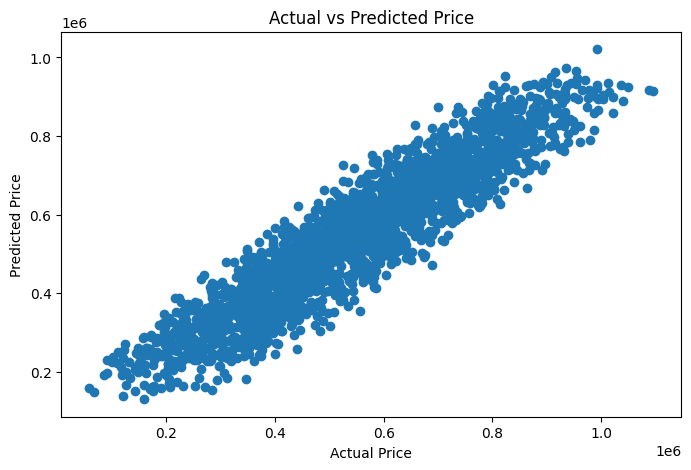

In [163]:
# Import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8,5))

# Scatter plot
plt.scatter(y_test, y_pred_rf)

# Axis labels
plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

# Graph title
plt.title("Actual vs Predicted Price")

# Show graph
plt.show()

In [164]:
# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort values
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display
importance_df

,Feature,Importance
2,Year,0.699112
3,KM_Driven,0.233585
1,Model,0.024516
0,Brand,0.013461
6,Seats,0.011703
5,Owner_Type,0.008844
4,Fuel_Type,0.008779


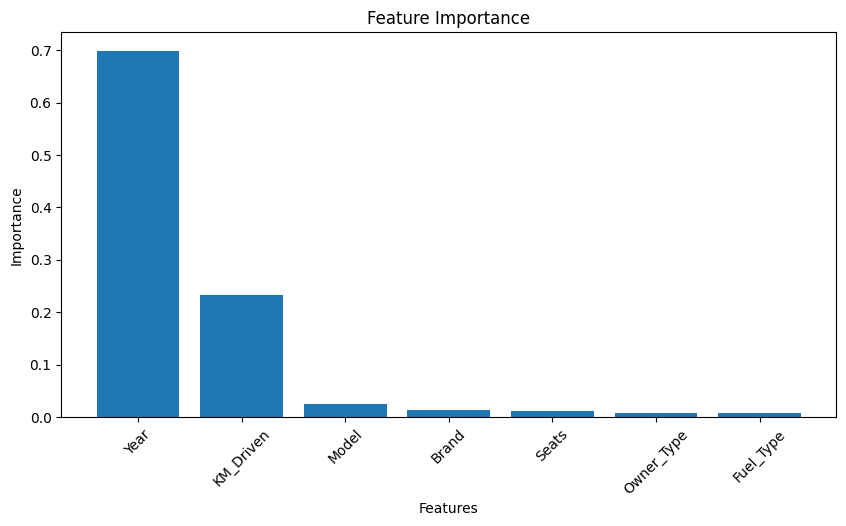

In [165]:
# Create figure
plt.figure(figsize=(10,5))

# Bar chart
plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

# Rotate labels
plt.xticks(rotation=45)

# Labels
plt.xlabel("Features")
plt.ylabel("Importance")

# Title
plt.title("Feature Importance")

# Show graph
plt.show()

In [166]:
# Example input

brand = "Tata"
model_name = "Punch"
year = 2023
km = 15000
fuel = "Petrol"
owner = "First Owner"
seats = 5

# Encode values
brand = le_brand.transform([brand])[0]
model_name = le_model.transform([model_name])[0]
fuel = le_fuel.transform([fuel])[0]
owner = le_owner.transform([owner])[0]

# Create dataframe
sample = pd.DataFrame(
    [[
        brand,
        model_name,
        year,
        km,
        fuel,
        owner,
        seats
    ]],
    columns=X.columns
)

# Predict price
price = rf.predict(sample)

print("Predicted Car Price:", round(price[0],2))

Predicted Car Price: 855784.42
